# Klassificering av High-Value Areas - California Housing Dataset

---

Beskriv bakgrund och uppgift och se till att få med spår B

## 1 Dataförståelse & EDA (kort med gott)

Skriv sammanfattning?

### Importera bibliotek

In [1]:
# Grundläggande bibliotek för datahantering & visualisering

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Scikit-learn: preprocessing & pipeline

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Scikit-learn: modeller

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Scikit-learn: modellval & utvärdering

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

### Läsa in datan och första överblick

In [2]:
# Läser in datan

df = pd.read_csv("../data/housing.csv")

In [3]:
# Antalet rader och kolumner

df.shape

(20640, 10)

In [4]:
# Datatyper

df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

### Saknade värden

In [5]:
# Saknade värden

missing_values_table = pd.DataFrame({
    "Saknade värden": df.isna().sum(),
    "Procent (%)": ((df.isna().sum() / len(df)) * 100).round(2)
})

print(missing_values_table)

                    Saknade värden  Procent (%)
longitude                        0          0.0
latitude                         0          0.0
housing_median_age               0          0.0
total_rooms                      0          0.0
total_bedrooms                 207          1.0
population                       0          0.0
households                       0          0.0
median_income                    0          0.0
median_house_value               0          0.0
ocean_proximity                  0          0.0


#### Hantering av saknade värden

Endast kolumnen total_bedrooms innehåller saknade värden (1 % av observationerna). 

Jag kommer ersätta dessa saknade värden med medianen med hjälp av en Imputer i Preprocess-steget. 

Då datasetet är förhållandevis litet (20640 observationer) vill jag inte droppa data i onödan. 

Medianen är robust mot outliers och kommer inte påverka fördelningen mycket åt något håll.



### Features

In [6]:
# Överblick av features och dess värden

df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


#### Scaling

Då de numeriska värdena går från negativa tal upp till flera hundratusen kommer en Scaler behövas i Preprocessing. 

Scaler:n används för att sätta alla variabler på en liknande skala så att ingen variabel får oproportionerligt stort inflytande på modellen.

### Target high_value

In [7]:
# Skapa binärt target high_value

house_value_limit = df["median_house_value"].quantile(0.8)

df["high_value"] = (df["median_house_value"] >= house_value_limit).astype(int)

In [8]:
# Verifiera fördelningen mellan 1:or och 0:or

high_value_tabel = pd.DataFrame({
    "Antal": df["high_value"].value_counts(sort=False),
    "Procent (%)": (df["high_value"].value_counts(normalize=True) * 100).round().astype(int)
})

high_value_tabel.loc["Summa"] = [high_value_tabel["Antal"].sum(), 100]

high_value_tabel.index = ["1 (topp 20 %)", "0 (ej topp 20 %)", "Summa"]

high_value_tabel

,Antal,Procent (%)
1 (topp 20 %),16510,80
0 (ej topp 20 %),4130,20
Summa,20640,100


#### Kommentera obalanserad data

En 20/80 fördelning av datan innebär att den blir obalanserad. 

Det blir därför viktigt att bevara klassfördelningen när datan delas upp Train/Test. Detta görs med stratify=y. 

Av samma anledning kommer StratifiedKFold användas vid CrossValidation. 

### Datans fördelning

In [12]:
df.describe(percentiles=[0.25, 0.5, 0.75, 0.8])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,high_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,0.200097
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,0.400082
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,0.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,0.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,0.000000
80%,-117.890000,37.810000,40.000000,3485.000000,718.600000,1908.000000,666.000000,5.109720,290000.000000,1.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,1.000000


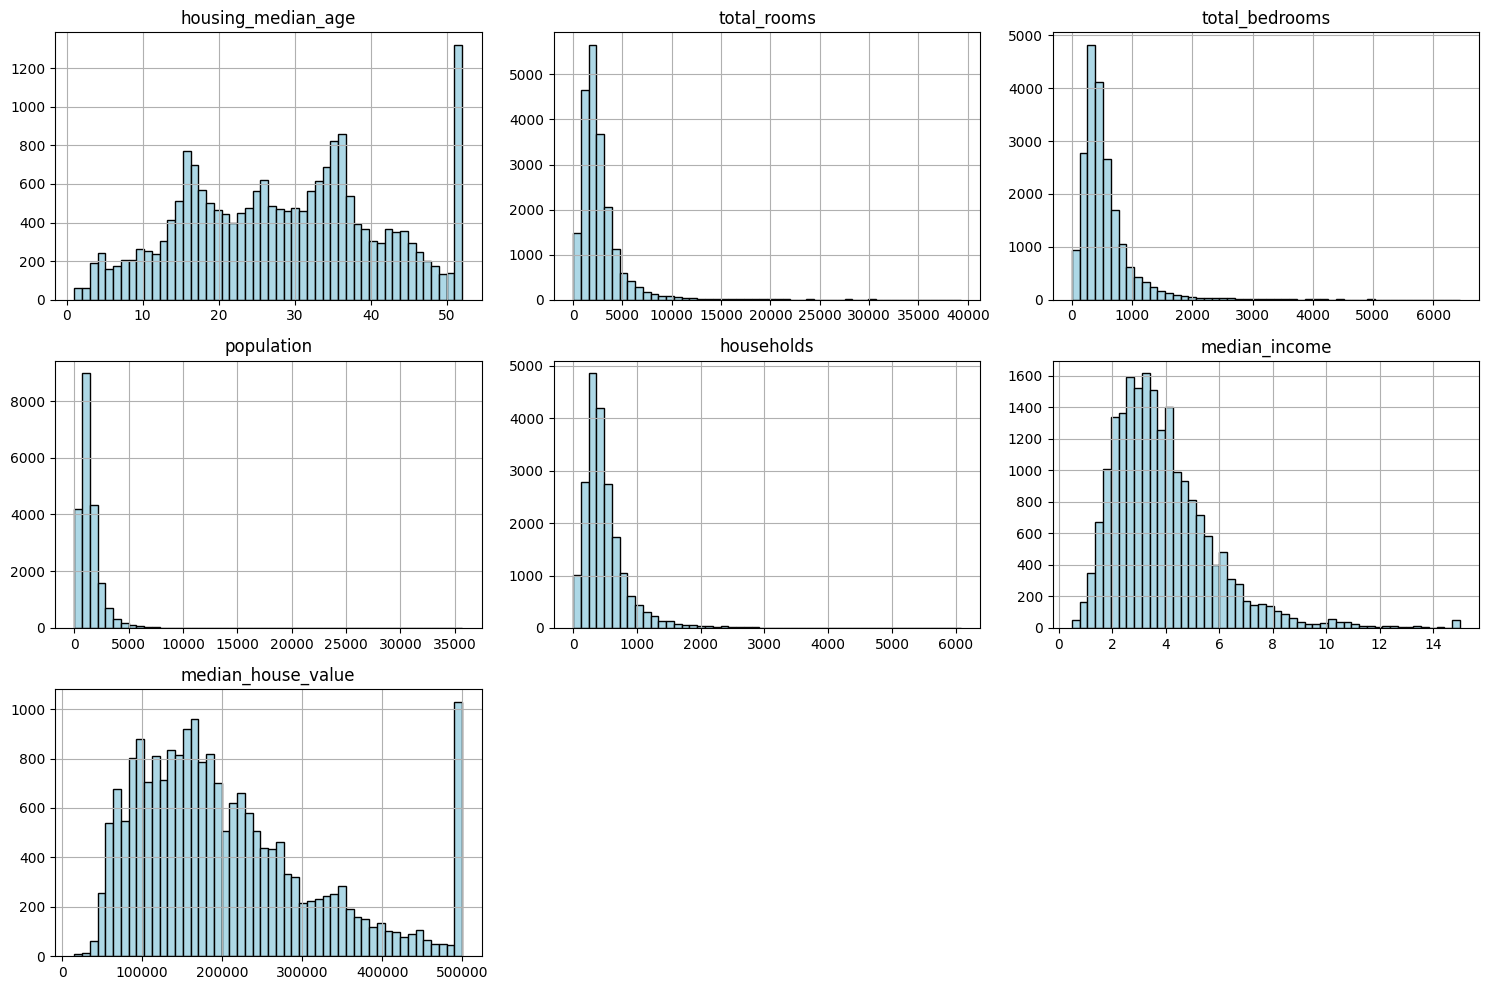

In [15]:
# Plotta histogram 

columns_to_plot = [
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "median_house_value"
]

df[columns_to_plot].hist(bins=50, figsize=(15,10), color="lightblue", edgecolor="black")

plt.tight_layout()
plt.show()

#### Kommentarer på fördelningen

##### "Capped" features

I histogrammet går det att utläsa att både housing_median_age och median_house_value är "capped". 

De sista staplarna (de sista bins:en) är mycket större än övriga staplar. 

Från describe()-tabellen går det att utläsa att housing_median_age är "capped" vid 52 år (max) och median_house_value är det vid 500 001 $ (max).

Att housing_median_age är capped vid 500 001 $ hade kunnat bli ett problem om det krockade med gränsvärdet för topp 20 %. 

Säg att 25 % av alla områden i datasetet har maxpriset 500 001 $. Att rättvist plocka ut de faktiska topp 20 % baserat på median_house_value hade då blivit omöjlgt. Det hade blivit random vilka 5 % som inte "fick vara med". Detta hade ju slutat med att modellen tränades med ett felaktigt facit. 

Men nu är gränsvärdet 290 000 $ (vilket går att utläsa ur describe()-tabellen (80 % percentile)), vilket är en bra bit ifrån 500 001 \$.

Att housing_median_age är capped på 52 år kan ge bekymmer om den nya datan som modellen används på inte är capped på samma sätt. 

Låt oss säga att 90 år gamla hus är dyrare än 52 år gamla hus. En trädmodell kommer behandla 90 år på samma sätt som 52 år och missar skillnaden. En linjär modell kan istället komma att överdriva värdet för det äldre huset. 

En lösning på detta är att i Preprocessing lägga till ett "capped"-steg. Vilket innebär att ny data kontrolleras och om median_housing_age är större än 52 så ändras det till 52.

##### Outliers och features med totalsummor istället för median

total_rooms: 75 % av alla områden har 3148 rum eller färre, men maxvärdet är 39 320 rum.

population: 75 % av alla områden har under 1725 invånare, men maxvärdet är 35 682 invånare. 

Dessa features tillsammans med total_bedrooms och households är dessutom de kolumner med summerade värden snarare än median. 

Ett maxvärde på 39 320 rum säger egentligen ingenting om man inte vet hur hur många hus det var i området. 

Totalt 39 320 rum i ett område med 10 000 hus? I snitt 3,9 rum per hus, rätt så normalt! 

Totalt 39 320 rum i ett område med 1 000 hus? Jäklar! 39 rum per hus??

Vilket ger oss två anledningar att med Feature Engineering ersätta features som inte säger så mycket (eller rent av kan säga fel saker) med nya features som är mer informativa. På så sätt försvinner också extremvärdena. 

Feature Engineering kommer genomföras i nästa avsnitt.

## 2 Split + preprocessing

- Dela datan i **train** och **test**
- Klassificering: använd stratifierad split (stratify) så att klasserna fördelas rimligt i train/test
- Preprocessing ska göras på ett sätt som undviker att testdata påverkar träningen

## 3 Modellering

- Skapa en **baseline**
- Träna minst **två** ytterligare modeller (totalt minst 3 inkl baseline)
- Jämför modellerna med en tydlig utvärderingsmetod (t.ex. cross-validation eller valideringsupplägg)

## 4 Välj och optimera en modell

- Välj **en** modell baserat på din jämförelse
- **Optimera den valda modellen** med hyperparameter-tuning (t.ex. GridSearchCV). Du väljer själv vilka parametrar som är relevanta
- Beskriv kort **vad du optimerade** och **vilken metric** du optimerade mot

## 5 Slutlig utvärdering på testdata + rekommendation

- Utvärdera din slutliga modell på **testdata** och rapportera resultatet
- Välj minst en relevant metric och motivera valet:
    - Klassificering: t.ex. F1 eller Recall/Precision
- Sammanfatta resultat tydligt (tabell rekommenderas)
Skriv en kort rekommendation: vilken modell skulle du ta vidare och varför?

## 6 Oövervakad inlärning 

### Bakgrund (case)

Ledningen vill inte bara ha en modell - de vill också förstå om det finns **naturliga grupper av områden** i datan. Om sådana grupper finns kan det hjälpa till att:

- Segmentera områden (t.ex. "typområden" som liknar varandra)
- Upptäcka ovanliga områden (avvikare)
- Och få en enklare överblick i datan innan man tar beslut

### Uppdrag

Du ska därför undersöka om datan verkar innehålla struktur genom att använda **PCA eller KMEANS** på ett rimligt urval av X-variabler (inte target)

### Syfte

Att se om vi kan:

- Sammanfatta datan i ett enklare "mönster" (PCA) eller
- Hitta grupper av liknande områden (KMeans)
- Och diskutera hur detta skulle kunna användas som beslutsstöd

### Krav

- Implementera PCA **eller** KMeans
- Visa resultat (figur/tabell)
- Tolka kort: vad kan vi lära oss, och vad är osäkert?

Använd endast X-variabler (inte target) och motivera kort vilka features du inkluderade. Kom ihåg att metoderna är känsliga för skalning. 